# Predicción de Producción Solar para La Habana

**Modelo de Machine Learning del gemelo digital fotovoltaico**

Este cuaderno entrena y evalúa el modelo que predice la producción de un sistema
fotovoltaico en La Habana a partir del pronóstico meteorológico.

## Idea general
- **Objetivo a predecir:** el *factor de capacidad* (fracción de la potencia máxima,
  entre 0 y 1) — adimensional, por lo que sirve para cualquier tamaño de instalación.
- **Entradas:** variables meteorológicas de Open-Meteo + geometría solar calculada con
  física (pvlib) para las coordenadas de La Habana.
- **Datos:** producción horaria de **PVGIS** (base satelital NSRDB) como "verdad", y
  clima histórico de **Open-Meteo**, 2010–2015 (52 584 horas).

> El detalle metodológico completo está en `modelos_train/README.md`.

## 1. Librerías

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Cargar el dataset

El dataset ya viene con las características (features) calculadas y el objetivo
(`capacity_factor`). Cada fila es una hora; el índice es la marca de tiempo en UTC.

In [2]:
df = pd.read_csv("datasets/havana_solar_training.csv", index_col="time")
df.index = pd.to_datetime(df.index, utc=True)

FEATURES = [c for c in df.columns if c != "capacity_factor"]

# Hora local (La Habana) y mes, para los análisis exploratorios.
local = df.index.tz_convert("America/Havana")
df["hora_local"] = local.hour
df["mes"] = local.month

print(f"{len(df):,} horas  |  {df.index.min()}  ..  {df.index.max()}")
print(f"{len(FEATURES)} características:")
print(FEATURES)
df[FEATURES + ["capacity_factor"]].head()

52,584 horas  |  2010-01-01 00:00:00+00:00  ..  2015-12-31 23:00:00+00:00
14 características:
['shortwave_radiation', 'clearsky_ghi', 'clearsky_index', 'solar_elevation', 'effective_irradiance', 'cloud_cover', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'temp_loss_factor', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


,shortwave_radiation,clearsky_ghi,clearsky_index,solar_elevation,effective_irradiance,cloud_cover,temperature_2m,relative_humidity_2m,wind_speed_10m,temp_loss_factor,hour_sin,hour_cos,month_sin,month_cos,capacity_factor
time,,,,,,,,,,,,,,,
2010-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,57,24.6,62,7.1,1.0,-0.965926,0.258819,-2.449294e-16,1.0,0.0
2010-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,40,23.8,66,8.7,1.0,-0.866025,0.500000,-2.449294e-16,1.0,0.0
2010-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,34,23.1,70,8.3,1.0,-0.707107,0.707107,-2.449294e-16,1.0,0.0
2010-01-01 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,28,22.6,75,7.9,1.0,-0.500000,0.866025,-2.449294e-16,1.0,0.0
2010-01-01 04:00:00+00:00,0.0,0.0,0.0,0.0,0.0,18,22.0,80,7.6,1.0,-0.258819,0.965926,-2.449294e-16,1.0,0.0


In [3]:
df[["shortwave_radiation", "clearsky_index", "solar_elevation",
    "cloud_cover", "temperature_2m", "capacity_factor"]].describe().round(3)

,shortwave_radiation,clearsky_index,solar_elevation,cloud_cover,temperature_2m,capacity_factor
count,52584.000,52584.000,52584.000,52584.000,52584.000,52584.000
mean,228.505,0.422,18.962,46.441,25.888,0.180
std,301.910,0.461,24.597,36.256,3.428,0.254
min,0.000,0.000,0.000,0.000,13.200,0.000
25%,0.000,0.000,0.000,12.000,23.700,0.000
50%,16.000,0.000,0.010,39.000,26.000,0.000
75%,458.000,0.877,38.631,85.000,28.200,0.362
max,1049.000,1.200,84.134,100.000,35.100,0.869


## 3. Análisis exploratorio (EDA)

### 3.1 Distribución del factor de capacidad
La mitad de las horas son nocturnas (producción = 0). Por eso más adelante medimos el
error **separando las horas de día**, que es lo que realmente importa.

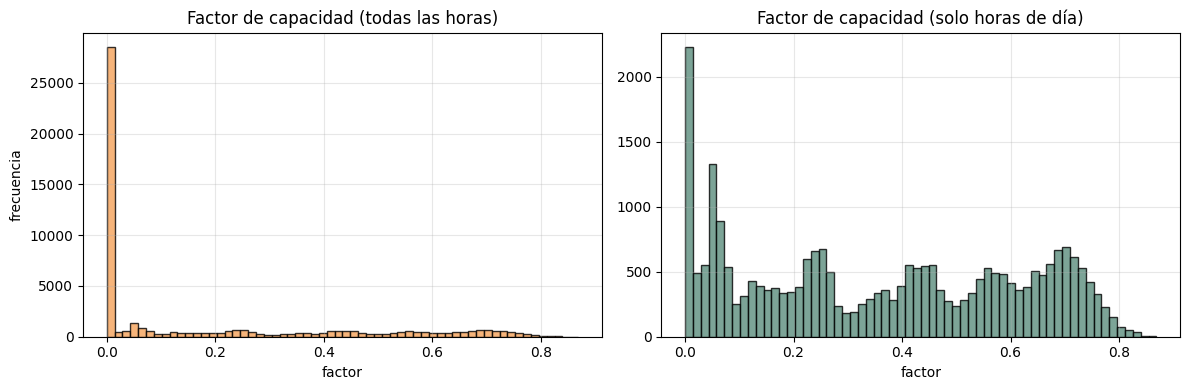

% de horas con producción 0: 52.4%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["capacity_factor"], bins=60, color="#f4a259", edgecolor="black", alpha=0.8)
ax[0].set(title="Factor de capacidad (todas las horas)", xlabel="factor", ylabel="frecuencia")
dia = df[df["solar_elevation"] > 0]
ax[1].hist(dia["capacity_factor"], bins=60, color="#5b8e7d", edgecolor="black", alpha=0.8)
ax[1].set(title="Factor de capacidad (solo horas de día)", xlabel="factor")
plt.tight_layout(); plt.show()
print(f"% de horas con producción 0: {(df['capacity_factor'] == 0).mean()*100:.1f}%")

### 3.2 Perfil diario y estacional
Producción media por hora del día y por mes (hora local de La Habana).

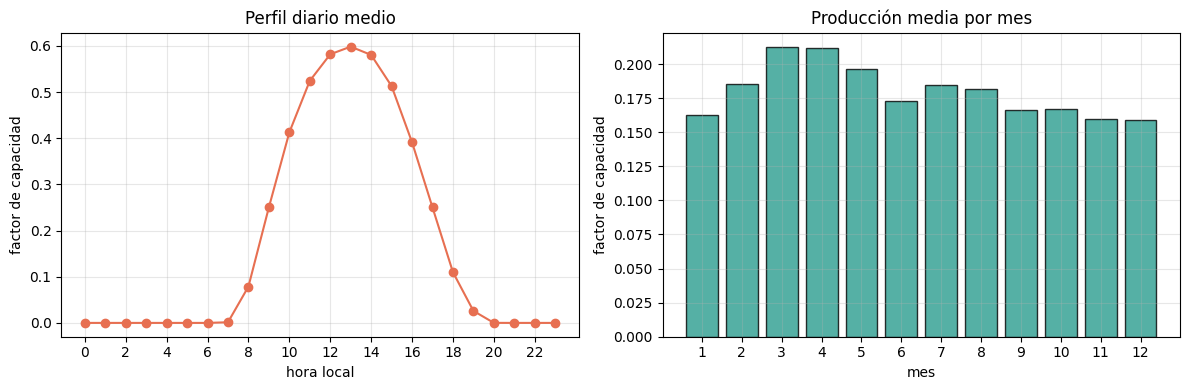

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h = df.groupby("hora_local")["capacity_factor"].mean()
ax[0].plot(h.index, h.values, marker="o", color="#e76f51")
ax[0].set(title="Perfil diario medio", xlabel="hora local", ylabel="factor de capacidad",
          xticks=range(0, 24, 2))
m = df.groupby("mes")["capacity_factor"].mean()
ax[1].bar(m.index, m.values, color="#2a9d8f", alpha=0.8, edgecolor="black")
ax[1].set(title="Producción media por mes", xlabel="mes", ylabel="factor de capacidad",
          xticks=range(1, 13))
plt.tight_layout(); plt.show()

### 3.3 Relación de las variables clave con la producción
La radiación y el índice de claridad son los predictores dominantes.

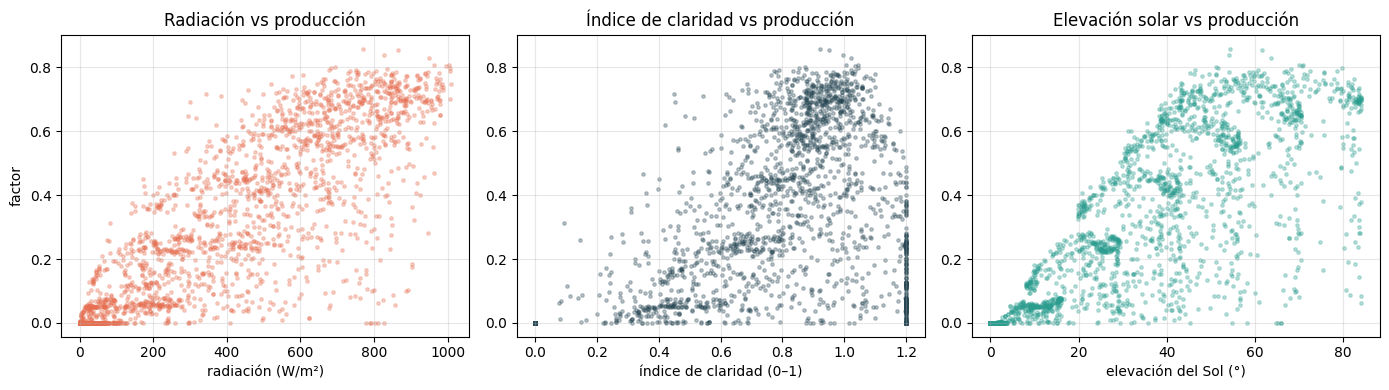

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
s = df.sample(4000, random_state=1)
ax[0].scatter(s["shortwave_radiation"], s["capacity_factor"], s=6, alpha=0.3, color="#e76f51")
ax[0].set(title="Radiación vs producción", xlabel="radiación (W/m²)", ylabel="factor")
ax[1].scatter(s["clearsky_index"], s["capacity_factor"], s=6, alpha=0.3, color="#264653")
ax[1].set(title="Índice de claridad vs producción", xlabel="índice de claridad (0–1)")
ax[2].scatter(s["solar_elevation"], s["capacity_factor"], s=6, alpha=0.3, color="#2a9d8f")
ax[2].set(title="Elevación solar vs producción", xlabel="elevación del Sol (°)")
plt.tight_layout(); plt.show()

### 3.4 Matriz de correlación

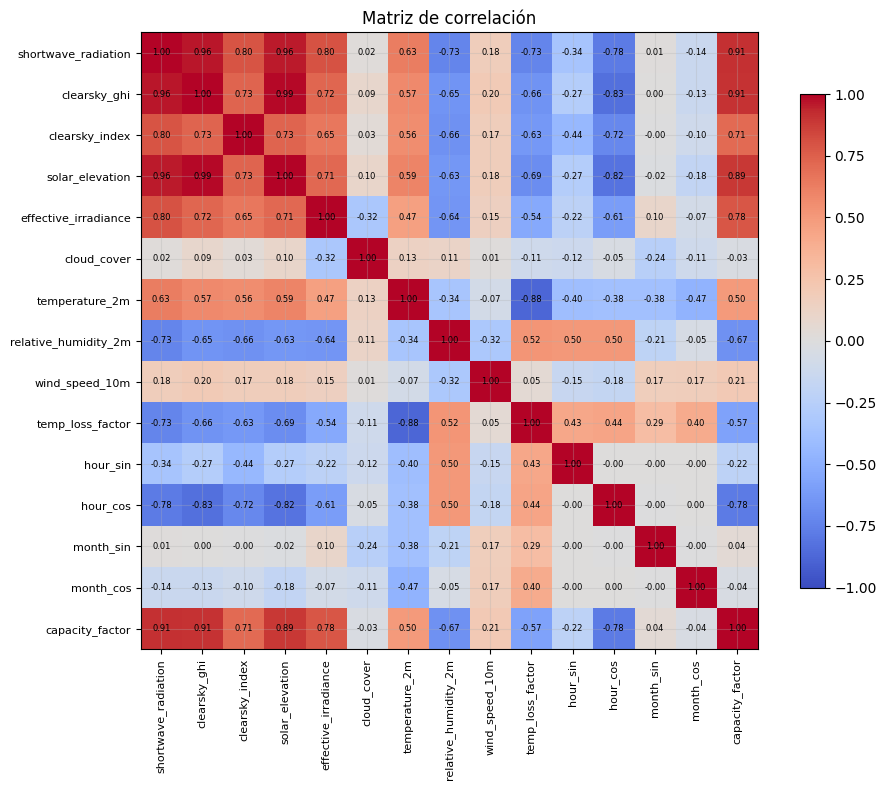

shortwave_radiation     0.910058
clearsky_ghi            0.905308
solar_elevation         0.885482
effective_irradiance    0.781301
clearsky_index          0.706874
temperature_2m          0.499750
wind_speed_10m          0.205378
month_sin               0.044462
cloud_cover            -0.032533
month_cos              -0.040038
hour_sin               -0.217077
temp_loss_factor       -0.573351
relative_humidity_2m   -0.668314
hour_cos               -0.780371
Name: capacity_factor, dtype: float64

In [7]:
corr = df[FEATURES + ["capacity_factor"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, shrink=0.8); ax.set_title("Matriz de correlación"); plt.tight_layout(); plt.show()
corr["capacity_factor"].drop("capacity_factor").sort_values(ascending=False)

## 4. Separación cronológica (sin fuga de datos)

**Clave metodológica:** NO barajamos las horas. Entrenamos con el **pasado** (primer
80 %) y evaluamos con el **futuro** (último 20 %). Así la métrica refleja cómo se
comportaría el modelo prediciendo días que nunca ha visto — lo que hará en operación.

In [8]:
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

X_train, y_train = train[FEATURES], train["capacity_factor"].clip(0, 1)
X_test,  y_test  = test[FEATURES],  test["capacity_factor"].clip(0, 1)

# Máscara de horas de día (el Sol está sobre el horizonte).
daylight = test["solar_elevation"].values > 0

print(f"Entrenamiento: {len(train):,} horas  ({train.index.min().date()} .. {train.index.max().date()})")
print(f"Prueba:        {len(test):,} horas  ({test.index.min().date()} .. {test.index.max().date()})")
print(f"Horas de día en prueba: {daylight.sum():,}")

Entrenamiento: 42,067 horas  (2010-01-01 .. 2014-10-19)
Prueba:        10,517 horas  (2014-10-19 .. 2015-12-31)
Horas de día en prueba: 5,161


## 5. Entrenar y comparar modelos

Comparamos tres familias con los mejores hiperparámetros encontrados (mediante
`TimeSeriesSplit`, ver el script de entrenamiento). El `HistGradientBoosting` incluye
**restricciones monótonas**: se le obliga a que más radiación nunca implique menos
producción.

In [9]:
MONO = {"shortwave_radiation": 1, "clearsky_ghi": 1, "clearsky_index": 1,
        "solar_elevation": 1, "effective_irradiance": 1, "cloud_cover": -1}
mono = [MONO.get(c, 0) for c in FEATURES]

models = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=4,
        max_features="sqrt", random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.02, max_leaf_nodes=127,
        min_samples_leaf=100, l2_regularization=1.0,
        monotonic_cst=mono, random_state=42),
}

def metrics(y_true, y_pred):
    return (float(np.sqrt(mean_squared_error(y_true, y_pred))),
            float(mean_absolute_error(y_true, y_pred)),
            float(r2_score(y_true, y_pred)))

rows, preds = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = np.clip(model.predict(X_test), 0, 1)
    preds[name] = p
    o_rmse, o_mae, o_r2 = metrics(y_test.values, p)
    d_rmse, d_mae, d_r2 = metrics(y_test.values[daylight], p[daylight])
    rows.append({"Modelo": name, "R² global": o_r2, "R² (día)": d_r2,
                 "RMSE (día)": d_rmse, "nRMSE (día) %": d_rmse * 100, "MAE (día)": d_mae})

resultados = pd.DataFrame(rows).set_index("Modelo").round(4)
resultados

,R² global,R² (día),RMSE (día),nRMSE (día) %,MAE (día)
Modelo,,,,,
Regresión Lineal,0.8796,0.7544,0.1236,12.3613,0.0881
Random Forest,0.8988,0.7893,0.1145,11.4507,0.0756
HistGradientBoosting,0.8981,0.7877,0.1149,11.4924,0.0748


In [10]:
mejor = resultados["RMSE (día)"].idxmin()
print(f"Mejor modelo (menor RMSE diurno): {mejor}")
print(resultados.loc[mejor])

Mejor modelo (menor RMSE diurno): Random Forest
R² global         0.8988
R² (día)          0.7893
RMSE (día)        0.1145
nRMSE (día) %    11.4507
MAE (día)         0.0756
Name: Random Forest, dtype: float64


## 6. Análisis del mejor modelo

### 6.1 Predicción vs valor real, y residuos

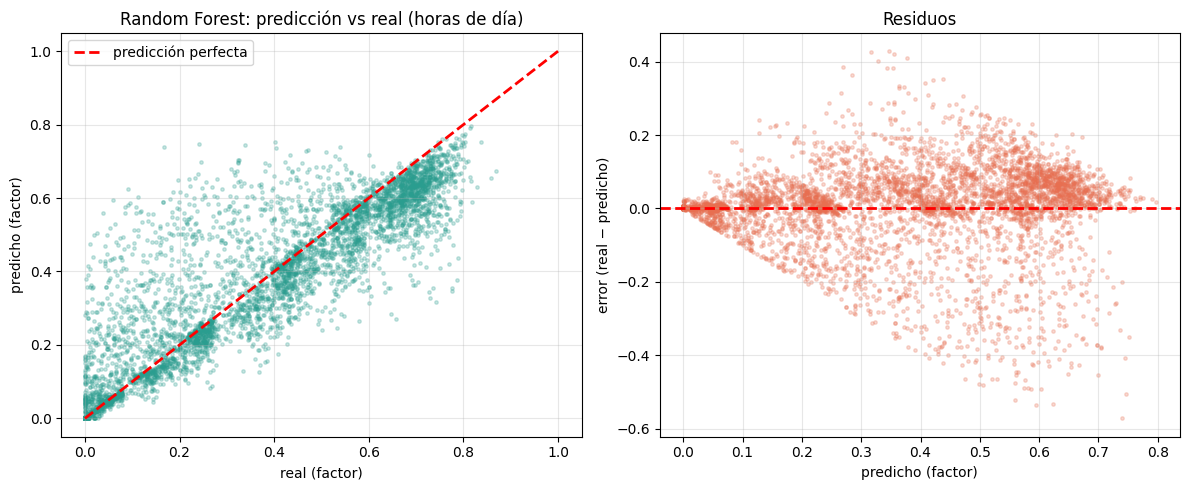

In [11]:
p = preds[mejor]
yt = y_test.values
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(yt[daylight], p[daylight], s=6, alpha=0.25, color="#2a9d8f")
ax[0].plot([0, 1], [0, 1], "r--", lw=2, label="predicción perfecta")
ax[0].set(title=f"{mejor}: predicción vs real (horas de día)",
          xlabel="real (factor)", ylabel="predicho (factor)"); ax[0].legend()
res = yt - p
ax[1].scatter(p[daylight], res[daylight], s=6, alpha=0.25, color="#e76f51")
ax[1].axhline(0, color="r", ls="--", lw=2)
ax[1].set(title="Residuos", xlabel="predicho (factor)", ylabel="error (real − predicho)")
plt.tight_layout(); plt.show()

### 6.2 Importancia de las características (Random Forest)

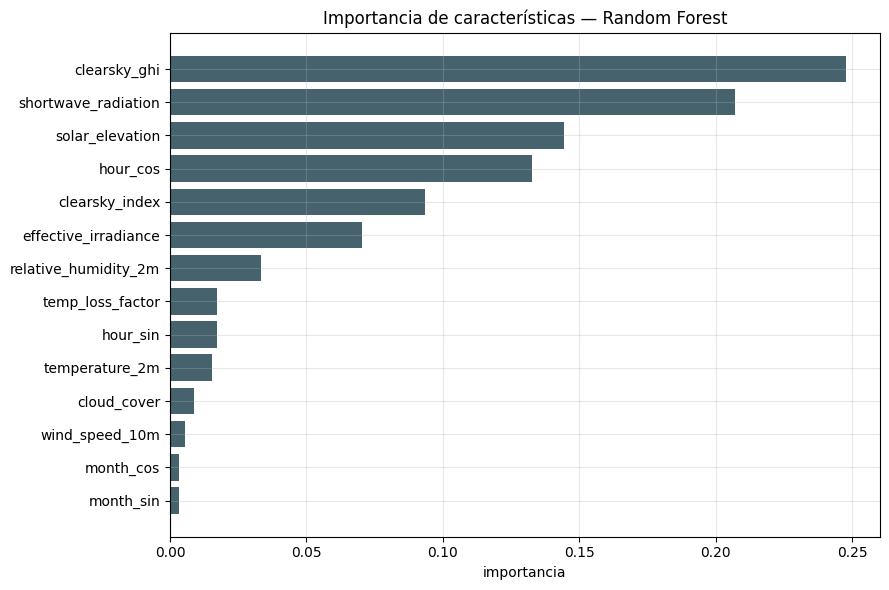

clearsky_ghi            0.247816
shortwave_radiation     0.207114
solar_elevation         0.144500
hour_cos                0.132547
clearsky_index          0.093541
effective_irradiance    0.070339
relative_humidity_2m    0.033519
temp_loss_factor        0.017292
hour_sin                0.017128
temperature_2m          0.015289
cloud_cover             0.008887
wind_speed_10m          0.005675
month_cos               0.003197
month_sin               0.003155
dtype: float64

In [12]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color="#264653", alpha=0.85)
ax.set(title="Importancia de características — Random Forest", xlabel="importancia")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

### 6.3 Ejemplo: un día completo predicho vs real
Elegimos automáticamente un día soleado del conjunto de prueba y comparamos la curva
de producción real (PVGIS) con la predicha por el modelo.

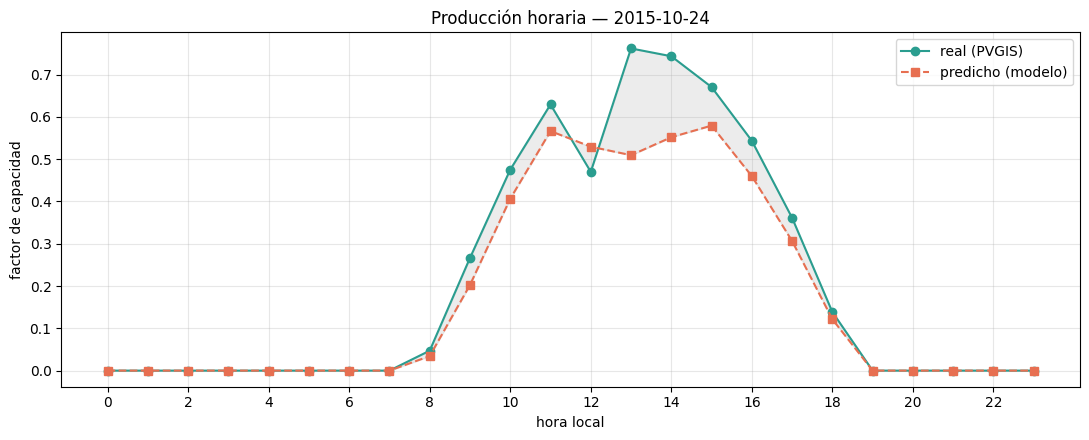

In [13]:
tl = test.copy()
tl["pred"] = preds[mejor]
tl["fecha"] = tl.index.tz_convert("America/Havana").date
tl["hora"] = tl.index.tz_convert("America/Havana").hour

# Día relativamente despejado (alto pico de producción) dentro de la prueba.
pico = tl.groupby("fecha")["capacity_factor"].max()
fecha = pico.sort_values().index[int(len(pico) * 0.85)]
dia = tl[tl["fecha"] == fecha].sort_values("hora")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(dia["hora"], dia["capacity_factor"], "o-", label="real (PVGIS)", color="#2a9d8f")
ax.plot(dia["hora"], dia["pred"], "s--", label="predicho (modelo)", color="#e76f51")
ax.fill_between(dia["hora"], dia["capacity_factor"], dia["pred"], alpha=0.15, color="gray")
ax.set(title=f"Producción horaria — {fecha}", xlabel="hora local",
       ylabel="factor de capacidad", xticks=range(0, 24, 2))
ax.legend(); plt.tight_layout(); plt.show()

## 7. Conclusiones

1. **Radiación e índice de claridad** son los predictores dominantes, seguidos de la
   geometría solar (elevación) — coherente con la física fotovoltaica.
2. Las tres familias de modelos **convergen a una precisión casi idéntica** (R² diurno
   ≈ 0.78–0.79). Esto indica que el límite de precisión lo impone el **dato** (el clima
   de Open-Meteo no explica el 100 % de la producción de PVGIS), no el algoritmo.
3. El **Random Forest** se selecciona por su menor RMSE diurno y se despliega en el
   backend.
4. El modelo predice el **factor de capacidad** (0–1); el sistema lo multiplica por la
   **capacidad real leída en tiempo real de los paneles configurados en la base de
   datos**, por lo que sirve para cualquier tamaño de instalación sin reentrenar.
5. La **separación cronológica** y las **métricas diurnas** garantizan que los
   resultados reportados son honestos y representativos de la operación real.

## Anexo: validación de hipótesis (fórmula física híbrida y LightGBM)

Dos preguntas de validación adicionales:

1. **¿Mejora combinar el modelo con una fórmula física de ingeniería?** Existe la cadena
   determinista PVWatts/pvlib que estima la producción a partir de la radiación:
   `GHI → directa/difusa (Erbs) → plano del panel POA (Hay-Davies) → temperatura de celda
   (Faiman) → potencia DC (PVWatts) + pérdidas`. Probamos usarla **sola**, en **ensemble**
   con el modelo, y como **característica extra**.
2. **¿LightGBM supera al Random Forest?**

In [14]:
import pvlib

def factor_capacidad_fisico(idx, ghi, tair, wind, tilt=20, az=180, perdidas=0.14):
    """Cadena física estándar de ingeniería FV (PVWatts/pvlib)."""
    loc = pvlib.location.Location(23.1136, -82.3666, tz="UTC", altitude=50)
    sp = loc.get_solarposition(idx)
    z, a = sp["apparent_zenith"], sp["azimuth"]
    erbs = pvlib.irradiance.erbs(ghi, z, idx)
    poa = pvlib.irradiance.get_total_irradiance(
        tilt, az, z, a, erbs["dni"].fillna(0), ghi, erbs["dhi"].fillna(0),
        dni_extra=pvlib.irradiance.get_extra_radiation(idx), model="haydavies",
    )["poa_global"].clip(lower=0).fillna(0)
    tcell = pvlib.temperature.faiman(poa, tair, wind)
    pdc = pvlib.pvsystem.pvwatts_dc(poa, tcell, pdc0=1.0, gamma_pdc=-0.004)
    return (pdc * (1 - perdidas)).clip(lower=0, upper=1).fillna(0)

df["cf_phys"] = factor_capacidad_fisico(
    df.index, df["shortwave_radiation"].clip(lower=0), df["temperature_2m"], df["wind_speed_10m"])

# Re-particionar para que train/test incluyan la nueva columna cf_phys.
train, test = df.iloc[:split], df.iloc[split:]
phys_test = test["cf_phys"].values
print("Factor de capacidad físico calculado.")

Factor de capacidad físico calculado.


In [15]:
rf_pred = preds["Random Forest"]

# Peso del ensemble afinado en una porción de validación DENTRO de train (sin tocar test)
vs = int(len(train) * 0.8)
rfv = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=4,
                            max_features="sqrt", random_state=42, n_jobs=-1)
rfv.fit(train[FEATURES].iloc[:vs], y_train.iloc[:vs])
val = train.iloc[vs:]; vday = val["solar_elevation"].values > 0
rfval = np.clip(rfv.predict(val[FEATURES]), 0, 1)
physval = val["cf_phys"].values; yval = y_train.iloc[vs:].values
ws = np.linspace(0, 1, 21)
w = min(ws, key=lambda w: np.sqrt(mean_squared_error(yval[vday], (w*rfval + (1-w)*physval)[vday])))
ens = np.clip(w*rf_pred + (1-w)*phys_test, 0, 1)

# Física como característica extra
rff = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=4,
                            max_features="sqrt", random_state=42, n_jobs=-1)
rff.fit(train[FEATURES + ["cf_phys"]], y_train)
rff_pred = np.clip(rff.predict(test[FEATURES + ["cf_phys"]]), 0, 1)

filas = [("Física sola (PVWatts)", phys_test),
         ("Random Forest (actual)", rf_pred),
         (f"Ensemble RF+física (w={w:.2f})", ens),
         ("RF + física como feature", rff_pred)]

# LightGBM (requiere libomp; import protegido)
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=63,
                             min_child_samples=50, random_state=42, n_jobs=-1,
                             verbose=-1, monotone_constraints=mono)
    lgbm.fit(X_train, y_train)
    filas.append(("LightGBM (monótono)", np.clip(lgbm.predict(X_test), 0, 1)))
except Exception as ex:
    print("LightGBM no disponible en este entorno:", type(ex).__name__)

tabla = []
for n, pr in filas:
    rmse = np.sqrt(mean_squared_error(y_test.values[daylight], pr[daylight]))
    mae = mean_absolute_error(y_test.values[daylight], pr[daylight])
    r2 = r2_score(y_test.values[daylight], pr[daylight])
    tabla.append({"Método": n, "RMSE (día)": rmse, "MAE (día)": mae, "R² (día)": r2})
pd.DataFrame(tabla).set_index("Método").round(4)

,RMSE (día),MAE (día),R² (día)
Método,,,
Física sola (PVWatts),0.1442,0.1024,0.6656
Random Forest (actual),0.1145,0.0756,0.7893
Ensemble RF+física (w=0.95),0.1146,0.0752,0.7890
RF + física como feature,0.1147,0.0753,0.7886
LightGBM (monótono),0.1206,0.0787,0.7661


**Conclusión del anexo:**

- La **fórmula física sola** (R² ≈ 0.67) es *peor* que el modelo entrenado (0.79).
- Combinarla **no mejora** la exactitud: ni por ensemble (el peso óptimo se va a ~0.95
  hacia el ML, es decir, "ignora la física") ni como característica extra (0.79 → 0.79).
- **LightGBM tampoco supera** al Random Forest.

**Por qué (argumento de defensa):** el modelo, entrenado sobre PVGIS, ya internalizó la
física mejor que una fórmula alimentada con la *misma* radiación de Open-Meteo. El error
dominante es la diferencia entre la radiación de Open-Meteo y la de PVGIS, que afecta por
igual a la física y al ML → combinarlos no puede cancelar un error común. La fórmula física
sí sería útil en dos escenarios: (a) si tuviéramos **producción medida real** (el ML
aprendería a corregir los residuos del modelo físico — *physics-informed ML*), o (b) como
**salvaguarda de robustez** en condiciones extremas fuera del rango de entrenamiento.

### Chequeo de sanidad: ¿es PVGIS una referencia confiable?

Como el modelo se entrena y evalúa contra PVGIS (no contra producción medida real),
verificamos que **PVGIS sea una referencia climatológicamente correcta** para La Habana,
con dos pruebas independientes: (1) el factor de capacidad anual frente a la literatura, y
(2) el acuerdo con la estimación física independiente en la climatología mensual.

In [16]:
# (1) Factor de capacidad anual = energía / (potencia x horas) = media horaria sobre todo el año
cf_pvgis = df["capacity_factor"].mean()
cf_fis = df["cf_phys"].mean()

# (2) Acuerdo en climatología mensual (energía sumada por mes)
local_naive = df.index.tz_convert("America/Havana").tz_localize(None)
mens = df.groupby(local_naive.to_period("M"))[["capacity_factor", "cf_phys"]].sum()
r_mensual = np.corrcoef(mens["capacity_factor"], mens["cf_phys"])[0, 1]
dif_energia = (mens["cf_phys"].sum() - mens["capacity_factor"].sum()) / mens["capacity_factor"].sum() * 100

pd.DataFrame({
    "Indicador": ["Factor de capacidad anual — PVGIS (objetivo)",
                  "Factor de capacidad anual — Física (independiente)",
                  "Literatura para Cuba/Caribe (FV fijo inclinado)",
                  "Correlación mensual PVGIS vs Física (72 meses)",
                  "Diferencia de energía total PVGIS vs Física"],
    "Valor": [f"{cf_pvgis*100:.1f}%", f"{cf_fis*100:.1f}%", "~18–21%",
              f"r = {r_mensual:.3f}", f"{dif_energia:+.1f}%"],
}).set_index("Indicador")

,Valor
Indicador,
Factor de capacidad anual — PVGIS (objetivo),18.0%
Factor de capacidad anual — Física (independiente),19.8%
Literatura para Cuba/Caribe (FV fijo inclinado),~18–21%
Correlación mensual PVGIS vs Física (72 meses),r = 0.920
Diferencia de energía total PVGIS vs Física,+10.0%


**Lectura:** ambos métodos semi-independientes caen dentro del rango publicado para
Cuba (~18–21 %) y concuerdan fuerte en la climatología mensual (r ≈ 0.92). Esto **no**
prueba exactitud horaria frente a la realidad (eso requiere medición de campo, señalada como
trabajo futuro), pero **descarta que PVGIS esté groseramente equivocado**: su climatología es
correcta. Por tanto, las métricas reportadas contra PVGIS son una referencia válida, con la
exactitud real **acotada por la de PVGIS**.

> **Importante para la defensa:** no se afirma que el modelo supere a la física frente a la
> producción real (la comparación R² 0.79 vs 0.67 mide *fidelidad a PVGIS*, y el modelo fue
> entrenado para eso). Se afirma que el modelo entrega estimaciones de calidad-PVGIS en
> tiempo real, algo que ni PVGIS (histórico) ni una fórmula genérica logran por sí solos.